# Q2 - Loan Prediction: Decision Tree Classifier

## Settings — the only cell you edit on exam day

In [1]:
# ===================================================================
# EXAM DAY - CHANGE ONLY WHAT IS MARKED BELOW, THEN RUN ALL
# ===================================================================

CSV_FILE  = "Data_Q2.csv"      # <<< CHANGE - the file they give you
TARGET    = "Loan_Status"      # <<< CHANGE - the column you are predicting
ID_COLUMN = "Loan_ID"          # <<< CHANGE - identifier to drop ("" if there is none)
TEST_SIZE = 0.40               # <<< CHANGE - 0.40 means 60% train / 40% test

TARGET_MAP  = {"Y": 1, "N": 0}                  # <<< CHANGE - how the target is labelled
CLASS_NAMES = ["Rejected (N)", "Approved (Y)"]  # <<< CHANGE - names for the plots

MAX_DEPTH    = 4               # tree depth - raise for accuracy, lower for a readable plot
RANDOM_STATE = 42

# If you do not know the column names yet, run this first:
#     import pandas as pd; print(pd.read_csv(CSV_FILE).columns.tolist())


## Step 1: Import libraries

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, confusion_matrix, classification_report)


## Step 2: Load the dataset

In [3]:
df = pd.read_csv(CSV_FILE)
df.head()


,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP01000,Male,Yes,1,Graduate,NaN,8306,0,28.0,360.0,1.0,Urban,Y
1,LP01001,Male,No,0,Graduate,No,4367,468,9.0,360.0,1.0,Semiurban,Y
2,LP01002,Male,No,1,Graduate,No,3407,1495,11.0,360.0,1.0,Urban,Y
3,LP01003,Female,No,0,Graduate,No,8731,2041,23.0,360.0,1.0,Semiurban,Y
4,LP01004,Male,No,3+,Graduate,No,10437,0,32.0,360.0,1.0,Semiurban,Y


## Step 3: Explore the data

In [4]:
print("Shape:", df.shape)     # expect 614 rows x 13 columns
df.info()


Shape: (614, 13)
<class 'pandas.DataFrame'>
RangeIndex: 614 entries, 0 to 613
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Loan_ID            614 non-null    str    
 1   Gender             601 non-null    str    
 2   Married            611 non-null    str    
 3   Dependents         599 non-null    str    
 4   Education          614 non-null    str    
 5   Self_Employed      582 non-null    str    
 6   ApplicantIncome    614 non-null    int64  
 7   CoapplicantIncome  614 non-null    int64  
 8   LoanAmount         592 non-null    float64
 9   Loan_Amount_Term   600 non-null    float64
 10  Credit_History     564 non-null    float64
 11  Property_Area      614 non-null    str    
 12  Loan_Status        614 non-null    str    
dtypes: float64(3), int64(2), str(8)
memory usage: 82.7 KB


## Step 4: Drop the identifier column

In [5]:
# An ID is unique to every row, so it cannot generalise to new applicants.
if ID_COLUMN in df.columns:
    df = df.drop(ID_COLUMN, axis=1)

df.head()


,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,Male,Yes,1,Graduate,NaN,8306,0,28.0,360.0,1.0,Urban,Y
1,Male,No,0,Graduate,No,4367,468,9.0,360.0,1.0,Semiurban,Y
2,Male,No,1,Graduate,No,3407,1495,11.0,360.0,1.0,Urban,Y
3,Female,No,0,Graduate,No,8731,2041,23.0,360.0,1.0,Semiurban,Y
4,Male,No,3+,Graduate,No,10437,0,32.0,360.0,1.0,Semiurban,Y


## Step 5: Handle missing values

In [6]:
print("Missing values before:")
print(df.isnull().sum())


Missing values before:
Gender               13
Married               3
Dependents           15
Education             0
Self_Employed        32
ApplicantIncome       0
CoapplicantIncome     0
LoanAmount           22
Loan_Amount_Term     14
Credit_History       50
Property_Area         0
Loan_Status           0
dtype: int64


## Fill the missing values

In [7]:
# Text columns -> mode (most common category)
for col in df.select_dtypes(include="object").columns:
    df[col] = df[col].fillna(df[col].mode()[0])

# Numeric columns -> median
for col in df.select_dtypes(include=np.number).columns:
    df[col] = df[col].fillna(df[col].median())

print("Missing values after:", df.isnull().sum().sum())


Missing values after: 0


C:\Users\Tatianv3\AppData\Local\Temp\ipykernel_26092\371755285.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  for col in df.select_dtypes(include="object").columns:


## Step 6: Convert the target into numbers

In [8]:
# Y (approved) = 1, N (rejected) = 0
df[TARGET] = df[TARGET].map(TARGET_MAP)

print(df[TARGET].value_counts())
print()
print("Approval rate:", round(df[TARGET].mean() * 100, 1), "%")


Loan_Status
1    493
0    121
Name: count, dtype: int64

Approval rate: 80.3 %


## Step 7: Encode the categorical features

In [9]:
# One-hot encoding turns text categories into 0/1 columns.
# drop_first=True removes one column per feature to avoid the dummy variable trap.
cat_cols = df.select_dtypes(include="object").columns
print("Encoding:", list(cat_cols))

df = pd.get_dummies(df, columns=cat_cols, drop_first=True)
df.head()


Encoding: ['Gender', 'Married', 'Dependents', 'Education', 'Self_Employed', 'Property_Area']


C:\Users\Tatianv3\AppData\Local\Temp\ipykernel_26092\670431028.py:3: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = df.select_dtypes(include="object").columns


,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Loan_Status,Gender_Male,Married_Yes,Dependents_1,Dependents_2,Dependents_3+,Education_Not Graduate,Self_Employed_Yes,Property_Area_Semiurban,Property_Area_Urban
0,8306,0,28.0,360.0,1.0,1,True,True,True,False,False,False,False,False,True
1,4367,468,9.0,360.0,1.0,1,True,False,False,False,False,False,False,True,False
2,3407,1495,11.0,360.0,1.0,1,True,False,True,False,False,False,False,False,True
3,8731,2041,23.0,360.0,1.0,1,False,False,False,False,False,False,False,True,False
4,10437,0,32.0,360.0,1.0,1,True,False,False,False,True,False,False,True,False


## Step 8: Features and target

In [10]:
X = df.drop(TARGET, axis=1)
y = df[TARGET]

print("Number of features:", X.shape[1])


Number of features: 14


## Q2.1 Split into training (60%) and testing (40%) sets

In [11]:
# stratify=y keeps the same approved/rejected ratio in both halves
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=TEST_SIZE, random_state=RANDOM_STATE, stratify=y)

print("Training rows:", X_train.shape[0])
print("Testing rows :", X_test.shape[0])


Training rows: 368
Testing rows : 246


## Q2.2 Train the Decision Tree Classifier

In [12]:
# max_depth limits how deep the tree grows.
# An unlimited tree memorises the training data (overfitting) and also
# becomes impossible to read on a plot.
model = DecisionTreeClassifier(criterion="gini", max_depth=MAX_DEPTH, random_state=RANDOM_STATE)
model.fit(X_train, y_train)


,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",4
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary <random_state>` for details.",42
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at 

## Q2.2 Predict on the test set

In [13]:
y_pred = model.predict(X_test)
y_pred[:20]


array([1, 1, 1, 1, 1, 1, 0, 1, 1, 0, 1, 0, 1, 0, 0, 1, 1, 1, 1, 1])

## Q2.3 Evaluate: Accuracy, Precision, Recall, F1-Score

In [14]:
print("Accuracy :", round(accuracy_score(y_test, y_pred), 4))
print("Precision:", round(precision_score(y_test, y_pred, zero_division=0), 4))
print("Recall   :", round(recall_score(y_test, y_pred, zero_division=0), 4))
print("F1 Score :", round(f1_score(y_test, y_pred, zero_division=0), 4))


Accuracy : 0.8659
Precision: 0.9064
Recall   : 0.9293
F1 Score : 0.9177


## Q2.3 Full classification report

In [15]:
print(classification_report(y_test, y_pred,
                            target_names=CLASS_NAMES,
                            zero_division=0))


              precision    recall  f1-score   support

Rejected (N)       0.67      0.60      0.64        48
Approved (Y)       0.91      0.93      0.92       198

    accuracy                           0.87       246
   macro avg       0.79      0.77      0.78       246
weighted avg       0.86      0.87      0.86       246



## Q2.3 Confusion matrix

[[ 29  19]
 [ 14 184]]


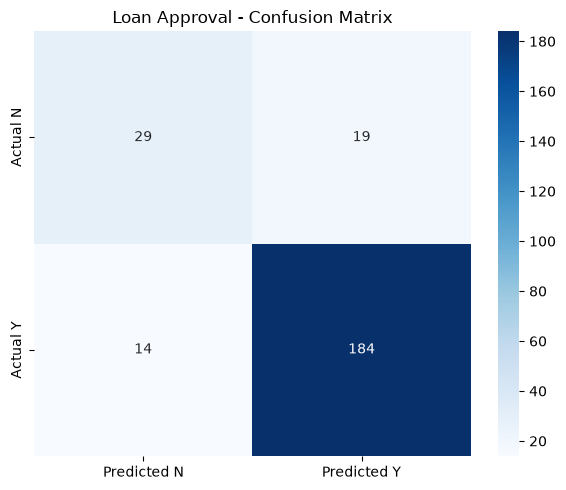

In [16]:
cm = confusion_matrix(y_test, y_pred)
print(cm)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Predicted N", "Predicted Y"],
            yticklabels=["Actual N", "Actual Y"])
plt.title("Loan Approval - Confusion Matrix")
plt.tight_layout()
plt.show()


## Q2.4 Visualise the Decision Tree

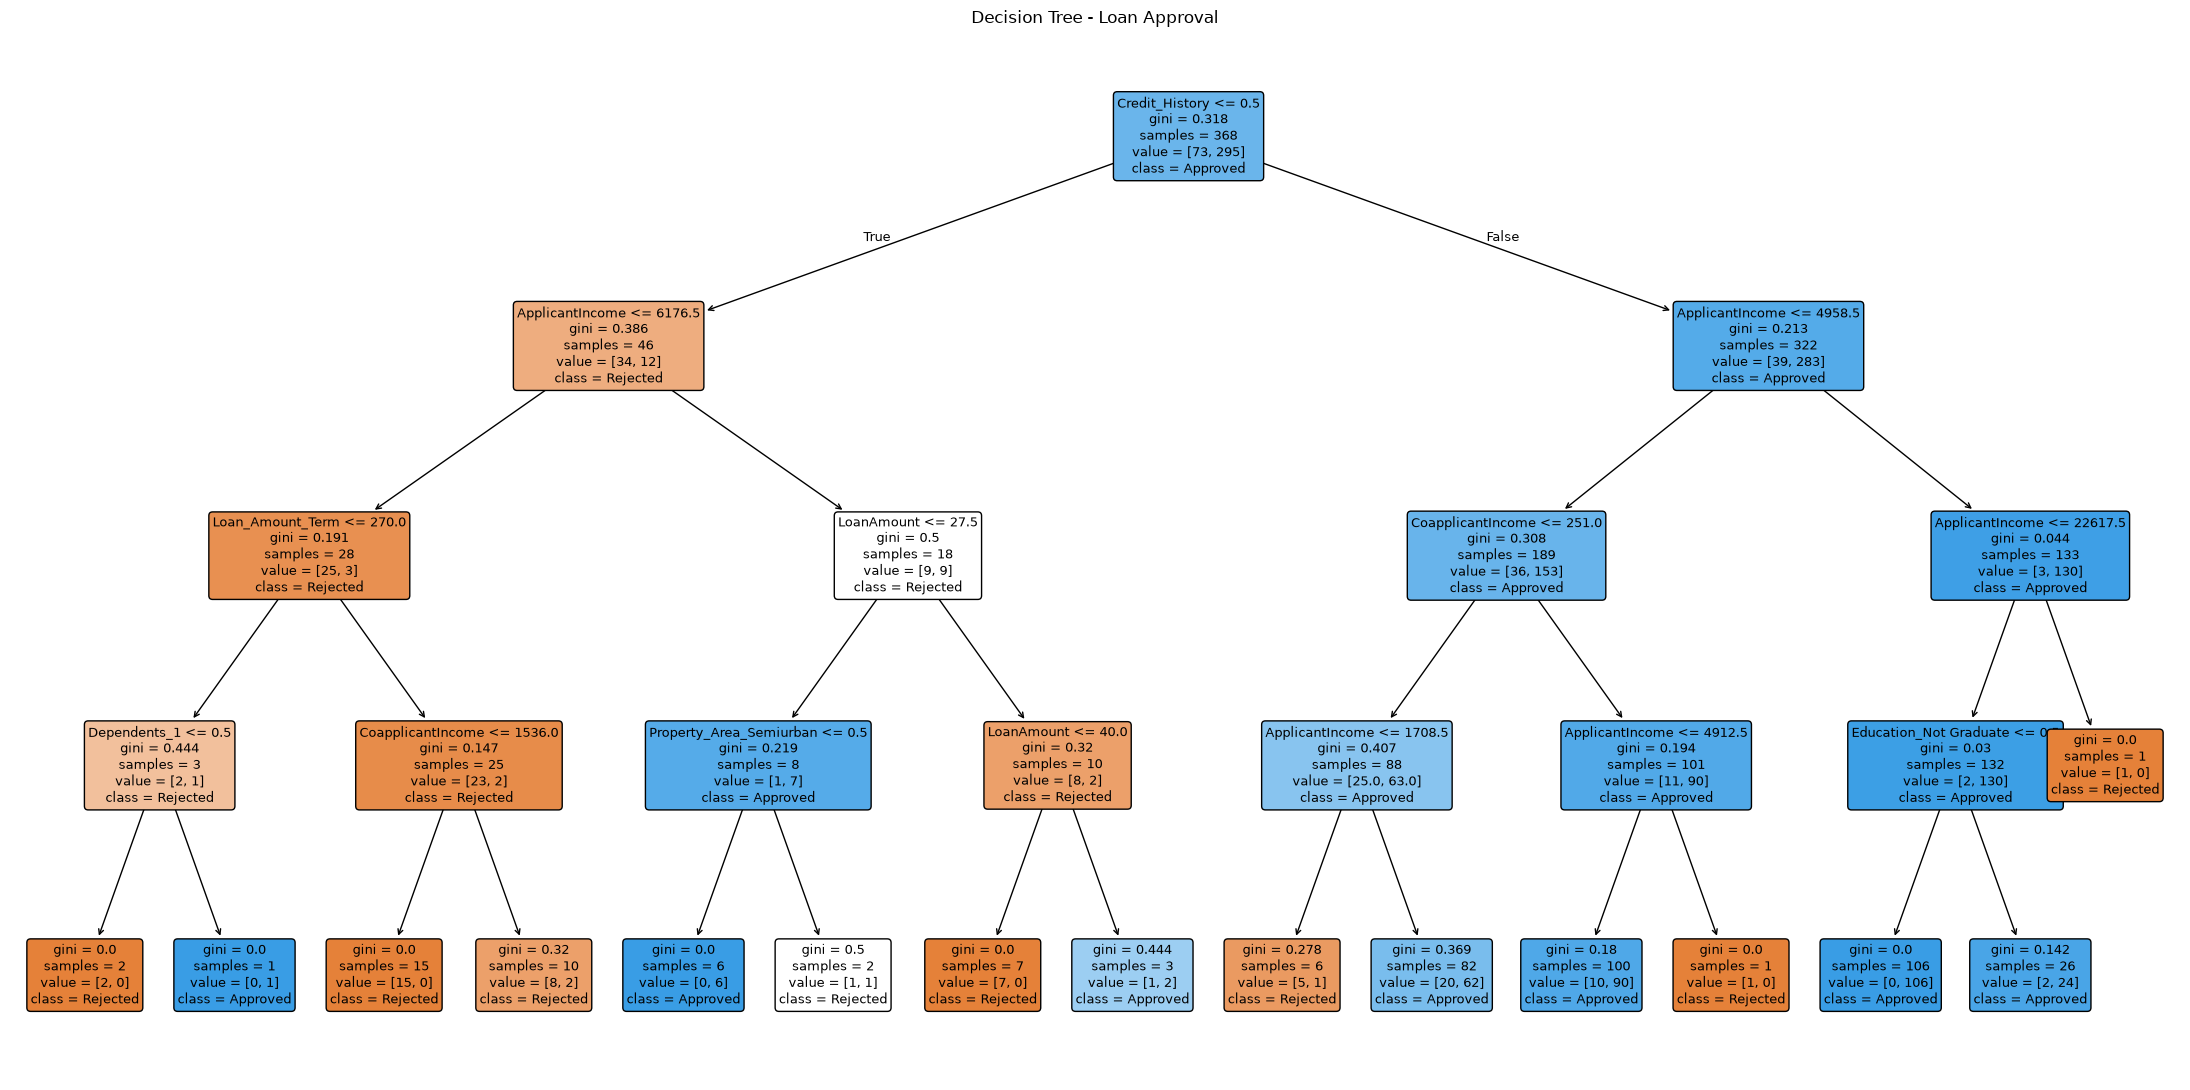

In [17]:
plt.figure(figsize=(22, 11))
plot_tree(model,
          feature_names=X.columns,
          class_names=["Rejected", "Approved"],
          filled=True, rounded=True, fontsize=9)
plt.title("Decision Tree - Loan Approval")
plt.tight_layout()
plt.show()


## Extra: which features drive the decision?

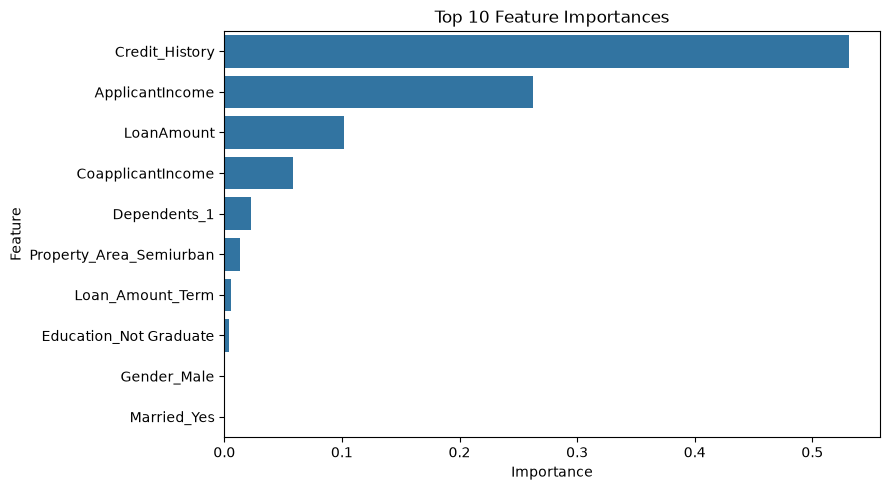

,Feature,Importance
4,Credit_History,0.5310
0,ApplicantIncome,0.2625
2,LoanAmount,0.1022
1,CoapplicantIncome,0.0581
7,Dependents_1,0.0230
12,Property_Area_Semiurban,0.0130
3,Loan_Amount_Term,0.0059
10,Education_Not Graduate,0.0043
5,Gender_Male,0.0000
6,Married_Yes,0.0000


In [18]:
importances = pd.DataFrame({
    "Feature": X.columns,
    "Importance": model.feature_importances_.round(4)
}).sort_values("Importance", ascending=False).head(10)

plt.figure(figsize=(9, 5))
sns.barplot(x="Importance", y="Feature", data=importances)
plt.title("Top 10 Feature Importances")
plt.tight_layout()
plt.show()

importances
